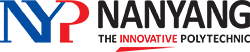

# IT2311 Assignment - Task 1a: Data Preparation

For this task, you are required to perform data understanding to examine your dataset and data cleaning to prepare the data for task 2 and 3.

Rename **DataPreparationStarter.ipynb** to **\<AdminNo\>_DataPreparation.ipynb** and complete the following sub-tasks:

Complete the following sub-tasks:

1. **Load Data**: Load your dataset
2. **Data Understanding**: Examine your dataset
3. **Data Cleaning**: Clean your data and perform all necessary pre-processing tasks
4. **Save Data**: Save the cleaned data for next task

For each sub-task, perform the necessary steps and **explain the rationale taken for each step in this Jupyter notebook**. 

**Done by: <Javian Ng 240592T>**

## Import libraries and download the packages

In [13]:
import pandas as pd
import numpy as np
import string
import re
from langdetect import detect, DetectorFactory


import nltk
nltk.download("stopwords")
nltk.download("wordnet")

from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.probability import FreqDist

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\glenv\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\glenv\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Load Data

In [14]:
df = pd.read_json("tasks/Task_1_TM_world_bank_projects_subset/Task_1_TM_world_bank_projects_subset.json", lines=True)
df.head(5)

,project_id,document_text,document_type
0,P170640,The World Bank\n Public Information and Awaren...,APPROVAL
1,P007810,Document of\nThe World Bank\nFOR OFFICIAL USE ...,APPROVAL
2,P002034,Document of\nFILE COPY The World Bank\nFOR OFF...,APPROVAL
3,P003542,Document of\nThe World Bank\nFOR OFFICIAL USE ...,REVIEW
4,P109683,Independent Evaluation Group (IEG) Implementat...,REVIEW


## Data Understanding

Dataset shape and columns: 
Shape: (3000, 3)

Columns: ['project_id', 'document_text', 'document_type']

Unique projects: 2774
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   project_id     3000 non-null   object
 1   document_text  3000 non-null   object
 2   document_type  3000 non-null   object
dtypes: object(3)
memory usage: 70.4+ KB
Document Type Distribution:
document_type
APPROVAL    1850
REVIEW      1150
Name: count, dtype: int64

Proportions:
document_type
APPROVAL    0.616667
REVIEW      0.383333
Name: proportion, dtype: float64
Word Count Statistics: 
count      3000.000000
mean      11481.027333
std       12528.379009
min           0.000000
25%        2358.750000
50%        6435.500000
75%       17417.250000
max      152471.000000
Name: word_count, dtype: float64


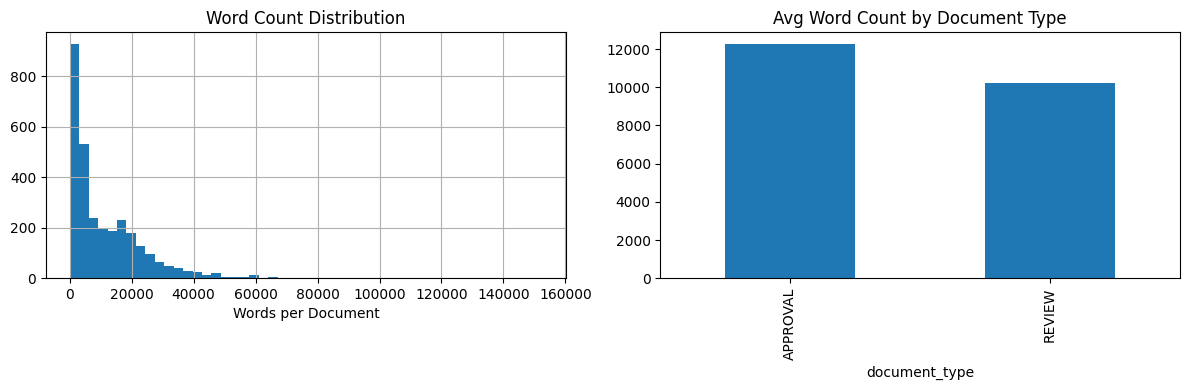

Example of data quality issue: 
The World Bank
 Public Information and Awareness Services for Vulnerable Communities in Lao PDR




 Project Information Document/
 Identification/Concept Stage (PID)
Public Disclosure Copy




 Concept Stage | Date Prepared/Updated: 23-Jun-2020 | Report No: PIDC185666




 Jun 24, 2020 Page 1 of 9
 The World Bank
 Public Information and Awareness Services for Vulnerable Communities in Lao PDR



 BASIC INFORMATION

 A\. Basic Project Data
 Environmental and
 Project ID Parent Project ID (if an

[Notice: extra whitespace, boilerplate phrases, formatting artifacts]


In [15]:
print("Dataset shape and columns: ")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nUnique projects: {df['project_id'].nunique()}")

df.info()

print("Document Type Distribution:")
print(df["document_type"].value_counts())
print(f"\nProportions:\n{df['document_type'].value_counts(normalize=True)}")

# Add word count analysis
df["word_count"] = df["document_text"].str.split().str.len()
print("Word Count Statistics: ")
print(df["word_count"].describe())

# Visualization - shows "interesting discoveries"
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["word_count"].hist(bins=50, ax=axes[0])
axes[0].set_title("Word Count Distribution")
axes[0].set_xlabel("Words per Document")

df.groupby("document_type")["word_count"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Avg Word Count by Document Type")
plt.tight_layout()
plt.show()

# Show actual data quality issues (evidence for your claims)
print("Example of data quality issue: ")
sample_text = df["document_text"].iloc[0][:500]
print(sample_text)
print("\n[Notice: extra whitespace, boilerplate phrases, formatting artifacts]")

Before applying LDA topic modelling, it is important to understand the dataset to ensure that the text is suitable for count-based analysis. The dataset contains three main columns: project_id, which uniquely identifies each World Bank project; document_text, which contains the textual content of each document; and document_type, which indicates the project stage (APPROVAL or REVIEW). Each row in the dataset represents a single document and is treated as one unit of analysis, which aligns with LDA’s assumption that each document is a mixture of latent topics inferred from word frequency and co-occurrence patterns.

The dataset includes both APPROVAL and REVIEW documents, which are written for different purposes and therefore exhibit differences in length and vocabulary. Approval documents are generally longer and more descriptive, outlining planned objectives and activities, while review documents focus on outcomes and evaluations. Longer documents may contain multiple themes, which can influence topic proportions during modelling. In addition, the raw text contains noise such as extra whitespace, repeated boilerplate phrases, and formatting artefacts from official reports. Since LDA is highly sensitive to vocabulary quality and word distributions, retaining such noise can distort topic–word probabilities and reduce topic coherence. As a result, data cleaning is necessary to standardise the text, remove non-informative content, and ensure that topics are driven by meaningful semantic patterns rather than artefacts.

## Dataset Source and Citation

The dataset used in this assignment is obtained from the Hugging Face repository
*lukesjordan/worldbank-project-documents*, which contains World Bank project
documents from 1947 to 2020.

Citation:
Jordan, Luke S. (2021). *World Bank Project Documents* [Dataset]. Hugging Face.
Available at: https://huggingface.co/datasets/lukesjordan/worldbank-project-documents

## Licensing and Attribution Notice

This dataset has been modified as part of this assignment through data cleaning,
filtering, and preprocessing steps performed by the student. These modifications
were carried out solely for academic purposes.

The original dataset creator, Luke S. Jordan, and the World Bank do not endorse
or take responsibility for the modified version of the dataset used in this
assignment.


## Data Cleaning


In [16]:
df_clean = df.copy()
original_count = len(df_clean)

# STEP 1: Standardise column types
df_clean["project_id"] = df_clean["project_id"].astype(str).str.strip()
df_clean["document_type"] = df_clean["document_type"].astype(str).str.strip().str.upper()

# Keep only known document types
df_clean = df_clean[df_clean["document_type"].isin(["APPROVAL", "REVIEW"])].copy()
print(f"After document_type filter: {len(df_clean):,}")

# STEP 2: Handle missing/empty text
df_clean["document_text"] = df_clean["document_text"].fillna("").astype(str)

# Remove literal nan variants (nan/NaN/NAN etc.)
df_clean["document_text"] = df_clean["document_text"].replace(
    to_replace=r"(?i)\bnan\b", value="", regex=True
)

# Normalise whitespace
df_clean["document_text"] = df_clean["document_text"].apply(lambda x: " ".join(x.split()))

# Remove empty documents
df_clean = df_clean[df_clean["document_text"].str.len() > 0].copy()
print(f"After empty-text removal:    {len(df_clean):,}")

# STEP 3: Remove duplicates
before_dedup = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["project_id", "document_type", "document_text"]).copy()
print(f"After deduplication:         {len(df_clean):,} (removed {before_dedup - len(df_clean):,})")

# STEP 4: Remove HTML tags
def remove_html_tags(text: str) -> str:
    return re.sub(r"<[^>]+>", " ", text)

df_clean["document_text"] = df_clean["document_text"].apply(remove_html_tags)

# STEP 5: Remove URLs, emails, and number-heavy patterns
def remove_noise_patterns(text: str) -> str:
    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    # Remove email addresses
    text = re.sub(r"\S+@\S+", " ", text)
    # Remove ID-like patterns (e.g., P123456, IDA-12345, ABC-1234)
    text = re.sub(r"\b[A-Z]{0,3}-?\d{4,}\b", " ", text)
    # Remove standalone numbers
    text = re.sub(r"\b\d+\b", " ", text)
    # Re-normalise whitespace after removals
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_clean["document_text"] = df_clean["document_text"].apply(remove_noise_patterns)

# STEP 6: Remove boilerplate phrases (regex-based)
BOILERPLATE_PHRASES = [
    "for official use only",
    "for official use",
    "world bank group",
    "world bank",
    "project development objective",
    "international development association",
    "implementation completion report",
    "international bank for reconstruction and development",
    "document of the world bank",
    "public disclosure authorized",
]

BOILERPLATE_PATTERN = re.compile(
    "|".join(re.escape(p) for p in BOILERPLATE_PHRASES),
    flags=re.IGNORECASE
)

def remove_boilerplate(doc: str) -> str:
    return BOILERPLATE_PATTERN.sub(" ", doc)

df_clean["document_text_cleaned"] = df_clean["document_text"].apply(remove_boilerplate)

# STEP 7: Text normalisation - stopwords, punctuation, lemmatisation
stop = set(stopwords.words("english"))
exclude = set(string.punctuation)
lemma = WordNetLemmatizer()

def clean_text(doc: str) -> str:
    # Replace punctuation with spaces (avoid word-joining)
    punc_free = "".join([ch if ch not in exclude else " " for ch in doc])

    tokens = []
    for w in punc_free.split():
        w_lower = w.lower().strip()
        if w_lower and (w_lower not in stop) and (not w_lower.isdigit()) and (len(w_lower) > 2):
            tokens.append(w_lower)

    lemmatised = [lemma.lemmatize(w) for w in tokens]
    return " ".join(lemmatised)

df_clean["clean_text"] = df_clean["document_text_cleaned"].apply(clean_text)

# STEP 8: Remove documents that are too short after cleaning
MIN_WORDS = 10
df_clean["clean_word_count"] = df_clean["clean_text"].str.split().str.len()

before_filter = len(df_clean)
df_clean = df_clean[df_clean["clean_word_count"] >= MIN_WORDS].copy()
print(f"After short-doc filter:      {len(df_clean):,} (removed {before_filter - len(df_clean):,})")


removed = original_count - len(df_clean)
print(f"Original documents:  {original_count:,}")
print(f"Final documents:     {len(df_clean):,}")
print(f"Documents removed:   {removed:,} ({removed/original_count*100:.1f}%)")

# Avg doc length before vs after (do not mutate df)
original_word_count = df["document_text"].fillna("").astype(str).str.split().str.len()
print(f"Original avg words/doc: {original_word_count.mean():.1f}")
print(f"Cleaned avg words/doc:  {df_clean['clean_word_count'].mean():.1f}")

# Vocabulary size before vs after (LDA-relevant evidence)
def vocab_size_from_series(text_series: pd.Series) -> int:
    return len(set(" ".join(text_series.fillna("").astype(str)).split()))

vocab_before = vocab_size_from_series(df["document_text"])
vocab_after = vocab_size_from_series(df_clean["clean_text"])

print(f"Vocab size before: {vocab_before:,}")
print(f"Vocab size after:  {vocab_after:,}")
print(f"Vocab reduced by:  {(1 - vocab_after / vocab_before)*100:.1f}%")

# Matched raw vs clean sample (same document, not index-based)
sample_pid = df_clean.iloc[0]["project_id"]
sample_dtype = df_clean.iloc[0]["document_type"]

raw_sample = df.loc[
    (df["project_id"].astype(str).str.strip() == sample_pid) &
    (df["document_type"].astype(str).str.strip().str.upper() == sample_dtype),
    "document_text"
].fillna("").astype(str).iloc[0]

clean_sample = df_clean.loc[
    (df_clean["project_id"] == sample_pid) &
    (df_clean["document_type"] == sample_dtype),
    "clean_text"
].iloc[0]

print("Raw text (first 500 chars):")
print(raw_sample[:500])
print("\nClean text (first 500 chars):")
print(clean_sample[:500])

print("\nColumns:", df_clean.columns.tolist())
print("Document types:", df_clean["document_type"].value_counts().to_dict())

# Reset index for clean output
df_clean = df_clean.reset_index(drop=True)

After document_type filter: 3,000
After empty-text removal:    2,989
After deduplication:         2,989 (removed 0)
After short-doc filter:      2,964 (removed 25)
Original documents:  3,000
Final documents:     2,964
Documents removed:   36 (1.2%)
Original avg words/doc: 11481.0
Cleaned avg words/doc:  6175.6
Vocab size before: 1,569,187
Vocab size after:  535,655
Vocab reduced by:  65.9%
Raw text (first 500 chars):
The World Bank
 Public Information and Awareness Services for Vulnerable Communities in Lao PDR




 Project Information Document/
 Identification/Concept Stage (PID)
Public Disclosure Copy




 Concept Stage | Date Prepared/Updated: 23-Jun-2020 | Report No: PIDC185666




 Jun 24, 2020 Page 1 of 9
 The World Bank
 Public Information and Awareness Services for Vulnerable Communities in Lao PDR



 BASIC INFORMATION

 A\. Basic Project Data
 Environmental and
 Project ID Parent Project ID (if an

Clean text (first 500 chars):
public information awareness service vulnerable

Data cleaning is a crucial prerequisite for LDA topic modelling because the algorithm relies entirely on accurate word frequency and co-occurrence patterns to infer latent topics. Noisy elements such as HTML tags, URLs, boilerplate institutional phrases, duplicated records, and inconsistent formatting introduce non-semantic tokens into the vocabulary, which can distort topic–word distributions and reduce topic coherence. Standardising column types, removing invalid records, and filtering duplicates ensure that each document represents a meaningful and unique unit of analysis, preventing certain content from being over-represented during model training.

In addition, handling missing or empty text, normalising whitespace, removing stopwords and punctuation, and applying lemmatisation help reduce vocabulary sparsity and consolidate semantically similar word forms. Very short documents are also removed, as they lack sufficient word co-occurrence information for stable topic inference. Together, these cleaning steps ensure that LDA focuses on semantically meaningful content rather than artefacts or noise, resulting in more coherent, interpretable, and reliable topics.

After data cleaning, the number of documents decreased from 3,000 to 2,964 due to duplicate and empty text removal, indicating effective noise reduction.

In [17]:
# Make results deterministic
DetectorFactory.seed = 42

def detect_language(text):
    try:
        return detect(text)
    except:
        return "unknown"

df_clean["language"] = df_clean["clean_text"].apply(detect_language)

# Keep English only
df_clean = df_clean[df_clean["language"] == "en"].copy()

# Drop helper column
df_clean.drop(columns=["language"], inplace=True)

print("Final dataset shape:", df_clean.shape)

print(df_clean)


Final dataset shape: (2865, 7)
     project_id                                      document_text  \
0       P170640  The World Bank Public Information and Awarenes...   
1       P007810  Document of The World Bank FOR OFFICIAL USE ON...   
2       P002034  Document of FILE COPY The World Bank FOR OFFIC...   
3       P003542  Document of The World Bank FOR OFFICIAL USE ON...   
4       P109683  Independent Evaluation Group (IEG) Implementat...   
...         ...                                                ...   
2959    P151169  ï»¿ The World Bank Supporting the economic inc...   
2960    P008821  ï»¿ ICRR Report Number : ICRR13937 IEG ICR Rev...   
2961    P084596  PROJECT INFORMATION DOCUMENT (PID) CONCEPT STA...   
2962    P009463  Documnt of The World Bank FOR OmCAL USE ONLY R...   
2963    P005262  DCC The W FOR OFFMC Rqet No\. PROJECT COMPLETI...   

     document_type  word_count  \
0         APPROVAL        2911   
1         APPROVAL        9297   
2         APPROVAL       1

Language filtering was performed to ensure that only English documents were used for topic modelling. Topic models rely on consistent vocabulary and linguistic structure, and including documents in multiple languages would fragment the word distributions and reduce topic coherence.

Language detection was applied at the document level using the `langdetect` library. Each document was classified by its dominant language, and only documents detected as English (`en`) were retained. Documents that could not be reliably classified were excluded to preserve data quality.

## Save Data

In [19]:
df_final = df_clean[['clean_text','document_type']]
print(df_final.head())
df_final = df_final.to_csv("240592T_data.csv", index=False, encoding="utf-8-sig", escapechar="\\")


                                          clean_text document_type
0  public information awareness service vulnerabl...      APPROVAL
1  report project completion report panama colon ...      APPROVAL
2  document file copy report uni report recommend...      APPROVAL
3  report china ningbo shanghai port project ning...        REVIEW
4  independent evaluation group ieg icr review ke...        REVIEW


## Submission
Export your completed work as HTML. Select **File** > **Download as** > **HTML (.html)**.